# SC-OTS Simplicial Complex Construction Pipeline Validation

This notebook validates the **persistent-homology-based feature interaction discovery** pipeline from the SC-OTS (Simplicial-Constrained Oblique Tree Sums) method.

**Pipeline Steps:**
1. Compute pairwise distance correlation (dCor) dissimilarity matrices
2. Verify triangle inequality for `1-dCor` vs `sqrt(1-dCor)` transforms
3. Build GUDHI Rips filtrations at multiple thresholds
4. Measure Precision/Recall/F1 of recovered simplices against ground-truth interactions
5. Analyze clique inflation artifacts
6. Compare HSIC (alternative to dCor) on friedman1
7. Evaluate enhanced feature-target interaction dCor method
8. Visualize results

**Dataset:** Friedman1 synthetic dataset (10 features, known `x0*x1` interaction)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# dcor, gudhi, hyppo, loguru — NOT on Colab, always install
_pip('dcor==0.6')
_pip('gudhi==3.11.0')
_pip('future')  # required by hyppo (provides 'past' module)
_pip('hyppo==0.4.0')
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib, networkx — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'networkx==3.6.1')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import base64
import io
import itertools
import json
import sys
import time

import dcor
import gudhi
import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from loguru import logger
from scipy.spatial.distance import squareform

## Data Loading

Load the mini demo dataset (friedman1: 50 examples, 10 features) from GitHub with local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-f5f9f2-simplicial-constrained-oblique-tree-sums/main/experiment_iter2_simplicial_comp/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {data['metadata']['n_datasets']} dataset(s), {data['metadata']['total_examples']} total examples")

Loaded 1 dataset(s), 100 total examples


## Configuration

Tunable parameters for the pipeline. Adjust `SUBSAMPLE_LIMIT` and `N_THRESHOLDS` to control runtime vs accuracy.

In [5]:
# ── Tunable parameters ────────────────────────────────────────
SUBSAMPLE_LIMIT = 2000     # dCor is O(n^2), subsample large datasets
RANDOM_STATE = 42
N_THRESHOLDS = 20          # number of Rips filtration thresholds
MAX_SIMPLEX_DIM = 4        # up to 4-simplices (5-way interactions)

# ── Dataset definitions ───────────────────────────────────────
DATASETS_WITH_GROUND_TRUTH = ["friedman1", "friedman3", "synth_3way", "synth_4way"]
REAL_DATASETS = [
    "diabetes", "breast_w", "california_housing", "wine_quality", "adult", "spambase"
]

# Ground truth interactions from the data formulas
GROUND_TRUTH = {
    "friedman1": {
        # y = 10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4
        "simplices": [frozenset({0, 1})],  # 1-simplex: x0*x1
        "active_features": {0, 1, 2, 3, 4},
        "noise_features": set(range(5, 10)),
    },
    "friedman3": {
        # y = arctan((x1*x2 - 1/(x1*x3)) / x0) → all 4 interact
        "simplices": [
            frozenset({0, 1, 2, 3}),  # 3-simplex
            frozenset({1, 2}),  # sub-interaction
            frozenset({1, 3}),  # sub-interaction
        ],
        "active_features": {0, 1, 2, 3},
    },
    "synth_3way": {
        # y = 5*x0*x1*x2 + 3*sin(pi*x3*x4) + 2*x0 + noise
        "simplices": [
            frozenset({0, 1, 2}),  # 3-way interaction
            frozenset({3, 4}),  # 2-way interaction
        ],
        "active_features": {0, 1, 2, 3, 4},
        "noise_features": set(range(5, 15)),
    },
    "synth_4way": {
        # y = 4*x0*x1*x2*x3 + 3*x4*x5 + 2*x0 + 1.5*x4 + noise
        "simplices": [
            frozenset({0, 1, 2, 3}),  # 4-way interaction
            frozenset({4, 5}),  # 2-way interaction
        ],
        "active_features": {0, 1, 2, 3, 4, 5},
        "noise_features": set(range(6, 20)),
    },
}

DOMAIN_NOTES = {
    "diabetes": "Pima Indians diabetes: expected BMI*skin_thickness, glucose*insulin interactions",
    "breast_w": "Wisconsin Breast Cancer: expected cell_size*cell_shape, bare_nuclei*bland_chromatin groupings",
    "california_housing": "California Housing: expected income*location, rooms*occupancy interactions",
    "wine_quality": "Wine Quality: expected acidity*pH, alcohol*residual_sugar interactions",
    "adult": "Adult Census: expected education*occupation, age*hours_per_week interactions",
    "spambase": "Spambase: expected word_freq*char_freq*capital_run_length groupings",
}

## Parse Datasets

Convert raw JSON examples into numpy arrays (feature matrix X, target vector y) for each dataset.

In [6]:
def load_all_datasets(raw: dict) -> dict:
    """Parse loaded JSON data into per-dataset structures."""
    datasets = {}
    for ds_entry in raw["datasets"]:
        ds_name = ds_entry["dataset"]
        examples = ds_entry["examples"]

        # Parse feature matrix and targets
        X = np.array([json.loads(ex["input"]) for ex in examples], dtype=np.float64)
        y_raw = [ex["output"] for ex in examples]

        task_type = examples[0]["metadata_task_type"]
        if task_type == "regression":
            y = np.array([float(v) for v in y_raw], dtype=np.float64)
        else:
            y = np.array([int(v) for v in y_raw], dtype=np.int64)

        feature_names = examples[0].get("metadata_feature_names", [f"f{i}" for i in range(X.shape[1])])
        known_interactions = None
        if "metadata_known_interactions" in examples[0]:
            known_interactions = json.loads(examples[0]["metadata_known_interactions"])

        datasets[ds_name] = {
            "X": X,
            "y": y,
            "feature_names": feature_names,
            "task_type": task_type,
            "n_features": X.shape[1],
            "n_samples": X.shape[0],
            "known_interactions": known_interactions,
            "category": examples[0].get("metadata_category", ""),
        }
        print(f"  {ds_name}: X={X.shape}, task={task_type}, features={len(feature_names)}")

    return datasets

datasets = load_all_datasets(data)
print(f"\nLoaded {len(datasets)} dataset(s)")

  friedman1: X=(100, 10), task=regression, features=10

Loaded 1 dataset(s)


## Step 1: Pairwise Distance Correlation Matrices

Compute pairwise dCor and Pearson |r| matrices for all features. dCor captures nonlinear dependencies unlike Pearson.

In [7]:
def compute_dcor_matrix(
    X: np.ndarray,
    subsample_limit: int = SUBSAMPLE_LIMIT,
    random_state: int = RANDOM_STATE,
) -> np.ndarray:
    """Compute pairwise distance correlation matrix for all features."""
    n_samples, n_feat = X.shape

    # Subsample if too many samples (dCor is O(n^2) per pair)
    if n_samples > subsample_limit:
        rng = np.random.RandomState(random_state)
        idx = rng.choice(n_samples, size=subsample_limit, replace=False)
        X_sub = X[idx]
    else:
        X_sub = X

    dcor_matrix = np.zeros((n_feat, n_feat))
    for i in range(n_feat):
        for j in range(i + 1, n_feat):
            try:
                val = dcor.distance_correlation(X_sub[:, i], X_sub[:, j])
                dcor_matrix[i, j] = val
                dcor_matrix[j, i] = val
            except Exception as e:
                print(f"dCor failed for features ({i}, {j}): {e}")
                dcor_matrix[i, j] = 0.0
                dcor_matrix[j, i] = 0.0
    np.fill_diagonal(dcor_matrix, 1.0)
    return dcor_matrix


def compute_pearson_matrix(X: np.ndarray) -> np.ndarray:
    """Compute pairwise Pearson |r| matrix (baseline)."""
    corr = np.corrcoef(X, rowvar=False)
    corr = np.abs(corr)
    np.fill_diagonal(corr, 1.0)
    return corr


def step1_dcor_matrices(datasets: dict) -> dict:
    """Step 1: Compute pairwise dCor and Pearson matrices for all datasets."""
    print("=" * 60)
    print("STEP 1: Pairwise Distance Correlation Matrices")
    print("=" * 60)

    dcor_matrices = {}
    pearson_matrices = {}

    for ds_name, ds in datasets.items():
        t0 = time.time()
        print(f"Computing dCor matrix for {ds_name} (n={ds['n_samples']}, p={ds['n_features']})")

        dcor_mat = compute_dcor_matrix(ds["X"])
        elapsed = time.time() - t0
        print(f"  dCor matrix computed in {elapsed:.1f}s")
        dcor_matrices[ds_name] = dcor_mat

        # Baseline: Pearson
        pearson_mat = compute_pearson_matrix(ds["X"])
        pearson_matrices[ds_name] = pearson_mat

    return {"dcor": dcor_matrices, "pearson": pearson_matrices}

matrices = step1_dcor_matrices(datasets)
dcor_matrices = matrices["dcor"]
pearson_matrices = matrices["pearson"]

STEP 1: Pairwise Distance Correlation Matrices
Computing dCor matrix for friedman1 (n=100, p=10)
  dCor matrix computed in 0.0s


## Step 1b: Enhanced Feature-Target Interaction dCor

For each feature pair (i, j), compute: `interaction_dcor[i,j] = dCor((X_i, X_j), y) - max(dCor(X_i, y), dCor(X_j, y))`. This captures the synergistic interaction contribution beyond what individual features provide.

In [8]:
def compute_interaction_dcor_matrix(
    X: np.ndarray,
    y: np.ndarray,
    subsample_limit: int = SUBSAMPLE_LIMIT,
    random_state: int = RANDOM_STATE,
) -> tuple:
    """Compute feature-target interaction dCor matrix."""
    n_samples, n_feat = X.shape

    if n_samples > subsample_limit:
        rng = np.random.RandomState(random_state)
        idx = rng.choice(n_samples, size=subsample_limit, replace=False)
        X_sub = X[idx]
        y_sub = y[idx].astype(np.float64)
    else:
        X_sub = X
        y_sub = y.astype(np.float64)

    # First compute individual feature-target dCor
    individual_dcor = np.zeros(n_feat)
    for i in range(n_feat):
        try:
            individual_dcor[i] = dcor.distance_correlation(X_sub[:, i], y_sub)
        except Exception:
            individual_dcor[i] = 0.0

    # Compute pairwise joint feature-target dCor
    interaction_matrix = np.zeros((n_feat, n_feat))
    for i in range(n_feat):
        for j in range(i + 1, n_feat):
            try:
                joint_dcor = dcor.distance_correlation(
                    X_sub[:, [i, j]], y_sub
                )
                # Interaction = joint effect minus best individual effect
                interaction = joint_dcor - max(individual_dcor[i], individual_dcor[j])
                interaction_matrix[i, j] = max(interaction, 0.0)  # clamp to non-negative
                interaction_matrix[j, i] = interaction_matrix[i, j]
            except Exception:
                pass

    # Diagonal = individual feature-target dCor (self-association)
    np.fill_diagonal(interaction_matrix, np.max(interaction_matrix) if np.max(interaction_matrix) > 0 else 1.0)

    return interaction_matrix, individual_dcor


def step1b_interaction_dcor(datasets: dict) -> dict:
    """Step 1b: Compute feature-target interaction dCor matrices for synthetic datasets."""
    print("=" * 60)
    print("STEP 1b: Feature-Target Interaction dCor (Enhanced)")
    print("=" * 60)

    interaction_matrices = {}
    individual_dcors = {}

    for ds_name in DATASETS_WITH_GROUND_TRUTH:
        if ds_name not in datasets:
            continue

        ds = datasets[ds_name]
        t0 = time.time()
        print(f"Computing interaction dCor for {ds_name} (n={ds['n_samples']}, p={ds['n_features']})")

        int_mat, ind_dcor = compute_interaction_dcor_matrix(ds["X"], ds["y"])
        elapsed = time.time() - t0
        print(f"  Interaction dCor matrix computed in {elapsed:.1f}s")

        # Log top interactions
        n_feat = int_mat.shape[0]
        upper = np.triu_indices(n_feat, k=1)
        pairs = list(zip(upper[0], upper[1], int_mat[upper]))
        pairs.sort(key=lambda x: x[2], reverse=True)
        print(f"  Top 5 interactions:")
        for i, j, v in pairs[:5]:
            print(f"    ({i},{j}): {v:.4f}")

        interaction_matrices[ds_name] = int_mat
        individual_dcors[ds_name] = ind_dcor

    return {"interaction_matrices": interaction_matrices, "individual_dcors": individual_dcors}

interaction_data = step1b_interaction_dcor(datasets)

STEP 1b: Feature-Target Interaction dCor (Enhanced)
Computing interaction dCor for friedman1 (n=100, p=10)
  Interaction dCor matrix computed in 0.0s
  Top 5 interactions:
    (1,3): 0.1068
    (4,7): 0.0460
    (8,9): 0.0321
    (0,3): 0.0306
    (5,8): 0.0186


## Step 2: Triangle Inequality Verification

Check whether `1-dCor` and `sqrt(1-dCor)` satisfy the triangle inequality. The sqrt transform is expected to produce fewer violations, making it a valid metric for Rips complex construction.

In [9]:
def check_triangle_inequality(D: np.ndarray) -> dict:
    """Check triangle inequality violations for a dissimilarity matrix."""
    n = D.shape[0]
    violations = []
    total_checks = 0

    for i, j, k in itertools.combinations(range(n), 3):
        for a, b, c in [(i, j, k), (j, k, i), (i, k, j)]:
            total_checks += 1
            lhs = D[a, c]
            rhs = D[a, b] + D[b, c]
            if lhs > rhs + 1e-12:
                mag = lhs - rhs
                violations.append({
                    "triple": (a, b, c),
                    "violation_magnitude": float(mag),
                    "relative_violation": float(mag / lhs) if lhs > 0 else 0.0,
                })

    result = {
        "total_checks": total_checks,
        "n_violations": len(violations),
        "violation_rate": len(violations) / total_checks if total_checks > 0 else 0.0,
    }
    if violations:
        result["max_violation_magnitude"] = max(v["violation_magnitude"] for v in violations)
        result["mean_violation_magnitude"] = float(np.mean([v["violation_magnitude"] for v in violations]))
        result["max_relative_violation"] = max(v["relative_violation"] for v in violations)
    else:
        result["max_violation_magnitude"] = 0.0
        result["mean_violation_magnitude"] = 0.0
        result["max_relative_violation"] = 0.0

    return result


def step2_triangle_inequality(dcor_matrices: dict) -> dict:
    """Step 2: Check triangle inequality for 1-dCor and sqrt(1-dCor) transforms."""
    print("=" * 60)
    print("STEP 2: Triangle Inequality Verification")
    print("=" * 60)

    results = {}
    for ds_name, dcor_mat in dcor_matrices.items():
        print(f"Checking triangle inequality for {ds_name} (p={dcor_mat.shape[0]})")

        # D_raw = 1 - dCor
        D_raw = 1.0 - dcor_mat
        np.fill_diagonal(D_raw, 0.0)

        # D_sqrt = sqrt(1 - dCor)
        D_sqrt = np.sqrt(np.clip(1.0 - dcor_mat, 0.0, None))
        np.fill_diagonal(D_sqrt, 0.0)

        raw_result = check_triangle_inequality(D_raw)
        raw_result["dissimilarity_type"] = "1-dCor"
        print(f"  1-dCor: {raw_result['n_violations']}/{raw_result['total_checks']} violations "
              f"(rate={raw_result['violation_rate']:.6f})")

        sqrt_result = check_triangle_inequality(D_sqrt)
        sqrt_result["dissimilarity_type"] = "sqrt(1-dCor)"
        print(f"  sqrt(1-dCor): {sqrt_result['n_violations']}/{sqrt_result['total_checks']} violations "
              f"(rate={sqrt_result['violation_rate']:.6f})")

        results[ds_name] = {"raw": raw_result, "sqrt": sqrt_result}

    return results

triangle_results = step2_triangle_inequality(dcor_matrices)

STEP 2: Triangle Inequality Verification
Checking triangle inequality for friedman1 (p=10)
  1-dCor: 0/360 violations (rate=0.000000)
  sqrt(1-dCor): 0/360 violations (rate=0.000000)


## Step 3: Rips Filtration Construction

Build Rips complexes using GUDHI from the dCor dissimilarity matrices. Extract persistence diagrams, Betti numbers, and simplices at each filtration threshold.

In [10]:
def build_rips_filtration(
    D: np.ndarray,
    max_dimension: int = MAX_SIMPLEX_DIM,
    n_thresholds: int = N_THRESHOLDS,
) -> dict:
    """Build Rips filtration using GUDHI and extract persistence/simplices."""
    n_feat = D.shape[0]

    # Build lower-triangular distance matrix for GUDHI
    lower_tri = []
    for i in range(n_feat):
        lower_tri.append(list(D[i, :i].astype(float)))

    # Threshold range from pairwise distances
    upper_tri_vals = D[np.triu_indices(n_feat, k=1)]
    d_min = float(upper_tri_vals.min())
    d_max = float(upper_tri_vals.max())

    # Cap max_edge_length to d_max for memory safety
    effective_max_dim = min(max_dimension, 3) if n_feat > 30 else max_dimension

    try:
        rips = gudhi.RipsComplex(distance_matrix=lower_tri, max_edge_length=d_max)
        st = rips.create_simplex_tree(max_dimension=effective_max_dim)
    except MemoryError:
        print(f"MemoryError with max_dim={effective_max_dim}, reducing to 2")
        rips = gudhi.RipsComplex(distance_matrix=lower_tri, max_edge_length=d_max)
        st = rips.create_simplex_tree(max_dimension=2)

    # Compute persistence
    st.compute_persistence()
    persistence_pairs = st.persistence()
    betti = st.betti_numbers()

    # Persistence diagrams per dimension
    persistence_diagrams = {}
    max_dim_found = max((dim for dim, _ in persistence_pairs), default=0)
    for dim in range(min(max_dim_found + 1, 5)):
        intervals = st.persistence_intervals_in_dimension(dim)
        if len(intervals) > 0:
            persistence_diagrams[dim] = intervals.tolist()
        else:
            persistence_diagrams[dim] = []

    # Largest gap heuristic for threshold selection
    all_deaths = sorted([d for _, (b, d) in persistence_pairs if d != float("inf") and np.isfinite(d)])
    if len(all_deaths) >= 2:
        gaps = [all_deaths[i + 1] - all_deaths[i] for i in range(len(all_deaths) - 1)]
        largest_gap_idx = int(np.argmax(gaps))
        gap_threshold = (all_deaths[largest_gap_idx] + all_deaths[largest_gap_idx + 1]) / 2
    else:
        gap_threshold = (d_min + d_max) / 2  # fallback: midpoint

    # Evaluation thresholds
    thresholds = np.linspace(d_min, d_max, n_thresholds).tolist()
    eval_thresholds = sorted(set(thresholds + [gap_threshold]))

    # Extract simplices at each threshold
    all_filtration = list(st.get_filtration())
    simplices_at_threshold = {}
    num_simplices_by_dim = {}

    for t in eval_thresholds:
        simplices_t = [
            frozenset(simplex)
            for simplex, filt in all_filtration
            if filt <= t and len(simplex) >= 2
        ]
        simplices_at_threshold[t] = simplices_t

        dim_counts = {}
        for s in simplices_t:
            d = len(s) - 1  # dimension of simplex
            dim_counts[d] = dim_counts.get(d, 0) + 1
        num_simplices_by_dim[t] = dim_counts

    return {
        "persistence_diagrams": persistence_diagrams,
        "betti_numbers": betti,
        "gap_threshold": gap_threshold,
        "d_min": d_min,
        "d_max": d_max,
        "thresholds": eval_thresholds,
        "simplices_at_threshold": simplices_at_threshold,
        "num_simplices_by_dim_and_threshold": {
            str(t): v for t, v in num_simplices_by_dim.items()
        },
    }


def step3_rips_filtrations(
    dcor_matrices: dict,
    triangle_results: dict,
) -> dict:
    """Step 3: Build Rips filtration for all datasets."""
    print("=" * 60)
    print("STEP 3: Rips Filtration Construction")
    print("=" * 60)

    rips_results = {}
    dissim_choice = {}

    for ds_name, dcor_mat in dcor_matrices.items():
        t0 = time.time()
        print(f"Building Rips filtration for {ds_name}")

        # Choose dissimilarity transform based on triangle inequality results
        tri = triangle_results.get(ds_name, {})
        raw_violations = tri.get("raw", {}).get("n_violations", 0)
        sqrt_violations = tri.get("sqrt", {}).get("n_violations", 0)

        # Use sqrt if it has fewer violations, otherwise raw
        if sqrt_violations < raw_violations:
            D = np.sqrt(np.clip(1.0 - dcor_mat, 0.0, None))
            chosen = "sqrt(1-dCor)"
        else:
            D = 1.0 - dcor_mat
            chosen = "1-dCor"
        np.fill_diagonal(D, 0.0)
        dissim_choice[ds_name] = chosen
        print(f"  Using {chosen} (raw violations={raw_violations}, sqrt violations={sqrt_violations})")

        result = build_rips_filtration(D)
        result["dissimilarity_used"] = chosen
        rips_results[ds_name] = result

        elapsed = time.time() - t0
        print(f"  Built in {elapsed:.1f}s, Betti={result['betti_numbers']}, "
              f"gap_threshold={result['gap_threshold']:.4f}")

    return rips_results

rips_results = step3_rips_filtrations(dcor_matrices, triangle_results)

STEP 3: Rips Filtration Construction
Building Rips filtration for friedman1
  Using 1-dCor (raw violations=0, sqrt violations=0)
  Built in 0.0s, Betti=[1, 0, 0, 0], gap_threshold=0.7743


## Step 4: Interaction Recovery (Precision/Recall/F1)

Evaluate how well the Rips filtration recovers ground-truth feature interactions on synthetic datasets. Also build enhanced Rips filtrations from the interaction dCor matrices.

In [11]:
def expand_simplicial_closure(simplices: list) -> set:
    """Expand a list of simplices to include all sub-simplices of dim >= 1."""
    expanded = set()
    for s in simplices:
        s_list = sorted(s)
        if len(s_list) >= 2:
            expanded.add(frozenset(s_list))
        for r in range(2, len(s_list) + 1):
            for combo in itertools.combinations(s_list, r):
                expanded.add(frozenset(combo))
    return expanded


def compute_pr_f1(predicted: set, gt_expanded: set) -> dict:
    """Compute precision, recall, F1 for predicted vs ground-truth simplices."""
    tp = predicted & gt_expanded
    fp = predicted - gt_expanded
    fn = gt_expanded - predicted

    precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0.0
    recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "tp": len(tp),
        "fp": len(fp),
        "fn": len(fn),
    }


def step4_interaction_recovery(rips_results: dict) -> dict:
    """Step 4: Precision/Recall/F1 on synthetic datasets."""
    print("=" * 60)
    print("STEP 4: Interaction Recovery (Precision/Recall)")
    print("=" * 60)

    interaction_recovery = {}

    for ds_name in DATASETS_WITH_GROUND_TRUTH:
        if ds_name not in rips_results:
            continue

        gt_info = GROUND_TRUTH[ds_name]
        gt_simplices = gt_info["simplices"]
        gt_expanded = expand_simplicial_closure(gt_simplices)
        print(f"{ds_name}: {len(gt_simplices)} ground-truth simplices, "
              f"{len(gt_expanded)} after closure expansion")

        rips = rips_results[ds_name]
        eval_thresholds = rips["thresholds"]
        simplices_at_t = rips["simplices_at_threshold"]
        gap_threshold = rips["gap_threshold"]

        metrics_by_threshold = {}
        for t in eval_thresholds:
            predicted = set(simplices_at_t[t])
            metrics = compute_pr_f1(predicted=predicted, gt_expanded=gt_expanded)
            metrics_by_threshold[str(round(t, 6))] = metrics

        # Find optimal threshold (max F1)
        best_t = max(eval_thresholds, key=lambda t: metrics_by_threshold[str(round(t, 6))]["f1"])
        best_metrics = metrics_by_threshold[str(round(best_t, 6))]

        # Gap threshold metrics
        gap_t_key = str(round(gap_threshold, 6))
        gap_metrics = metrics_by_threshold.get(gap_t_key, {"f1": 0.0})

        d_range = rips["d_max"] - rips["d_min"]
        discrepancy = abs(best_t - gap_threshold) / d_range if d_range > 0 else 0.0

        interaction_recovery[ds_name] = {
            "f1_at_optimal": best_metrics["f1"],
            "optimal_threshold": round(best_t, 6),
            "precision_at_optimal": best_metrics["precision"],
            "recall_at_optimal": best_metrics["recall"],
            "f1_at_gap": gap_metrics["f1"] if isinstance(gap_metrics, dict) and "f1" in gap_metrics else 0.0,
            "gap_threshold": round(gap_threshold, 6),
            "threshold_discrepancy_normalized": round(discrepancy, 4),
            "gt_simplices_count": len(gt_expanded),
            "metrics_by_threshold": metrics_by_threshold,
        }
        print(f"  {ds_name}: F1@optimal={best_metrics['f1']:.3f} (t={best_t:.4f}), "
              f"F1@gap={gap_metrics.get('f1', 0.0):.3f} (t={gap_threshold:.4f})")

    return interaction_recovery

interaction_recovery = step4_interaction_recovery(rips_results)

STEP 4: Interaction Recovery (Precision/Recall)
friedman1: 1 ground-truth simplices, 1 after closure expansion
  friedman1: F1@optimal=1.000 (t=0.7639), F1@gap=1.000 (t=0.7743)


## Step 5: Clique Inflation Analysis

Analyze whether spurious higher-dimensional simplices arise from clique inflation (all faces present implies the clique is included, even if the higher-order interaction doesn't exist).

In [12]:
def step5_clique_inflation(rips_results: dict) -> dict:
    """Step 5: Analyze clique inflation artifacts in Rips complex."""
    print("=" * 60)
    print("STEP 5: Clique Inflation Analysis")
    print("=" * 60)

    clique_inflation = {}

    for ds_name in DATASETS_WITH_GROUND_TRUTH:
        if ds_name not in rips_results:
            continue

        gt_info = GROUND_TRUTH[ds_name]
        gt_expanded = expand_simplicial_closure(gt_info["simplices"])

        rips = rips_results[ds_name]
        gap_threshold = rips["gap_threshold"]
        rips_simplices = rips["simplices_at_threshold"][gap_threshold]
        rips_set = set(rips_simplices)

        print(f"Analyzing clique inflation for {ds_name} at gap_threshold={gap_threshold:.4f}")

        dim_analysis = {}
        for dim in [1, 2, 3]:
            simplices_of_dim = [s for s in rips_simplices if len(s) == dim + 1]
            genuine = [s for s in simplices_of_dim if s in gt_expanded]
            spurious = [s for s in simplices_of_dim if s not in gt_expanded]

            # Check if spurious simplices are due to clique inflation
            inflation_confirmed = []
            for s in spurious:
                faces = [frozenset(c) for c in itertools.combinations(s, dim)]
                if all(f in rips_set for f in faces):
                    inflation_confirmed.append(sorted(list(s)))

            inflation_rate = len(inflation_confirmed) / len(simplices_of_dim) if simplices_of_dim else 0.0

            dim_analysis[str(dim)] = {
                "total_simplices": len(simplices_of_dim),
                "genuine": len(genuine),
                "spurious_total": len(spurious),
                "spurious_inflation": len(inflation_confirmed),
                "inflation_rate": round(inflation_rate, 4),
            }
            if simplices_of_dim:
                print(f"  dim={dim}: {len(simplices_of_dim)} total, {len(genuine)} genuine, "
                      f"{len(inflation_confirmed)} inflation (rate={inflation_rate:.3f})")

        clique_inflation[ds_name] = dim_analysis

    return clique_inflation

clique_inflation = step5_clique_inflation(rips_results)

STEP 5: Clique Inflation Analysis
Analyzing clique inflation for friedman1 at gap_threshold=0.7743
  dim=1: 1 total, 1 genuine, 0 inflation (rate=0.000)


## Step 6: HSIC Comparison & Enhanced Rips & Pearson Baseline

Compare HSIC (Hilbert-Schmidt Independence Criterion) against dCor on friedman1. Also build enhanced Rips filtrations from the interaction dCor matrices and a Pearson correlation baseline.

In [13]:
def compute_hsic_matrix(X: np.ndarray, subsample_limit: int = SUBSAMPLE_LIMIT) -> np.ndarray:
    """Compute HSIC-based association matrix."""
    from hyppo.independence import Hsic

    n_samples, n_feat = X.shape
    if n_samples > subsample_limit:
        rng = np.random.RandomState(RANDOM_STATE)
        idx = rng.choice(n_samples, size=subsample_limit, replace=False)
        X_sub = X[idx]
    else:
        X_sub = X

    hsic_matrix = np.zeros((n_feat, n_feat))
    for i in range(n_feat):
        for j in range(i + 1, n_feat):
            try:
                stat, _ = Hsic().test(X_sub[:, i:i + 1], X_sub[:, j:j + 1], auto=True)
                hsic_matrix[i, j] = stat
                hsic_matrix[j, i] = stat
            except Exception:
                hsic_matrix[i, j] = 0.0
                hsic_matrix[j, i] = 0.0

    max_val = hsic_matrix.max()
    if max_val > 0:
        np.fill_diagonal(hsic_matrix, max_val)
    else:
        np.fill_diagonal(hsic_matrix, 1.0)

    return hsic_matrix


def step6_hsic_comparison(
    datasets: dict,
    dcor_matrices: dict,
    rips_results: dict,
    interaction_recovery: dict,
) -> dict:
    """Step 6: Compare HSIC vs dCor on friedman1."""
    print("=" * 60)
    print("STEP 6: HSIC Comparison (friedman1)")
    print("=" * 60)

    ds_name = "friedman1"
    if ds_name not in datasets:
        print("friedman1 not found, skipping HSIC comparison")
        return {"skipped": True, "reason": "friedman1 not found"}

    X = datasets[ds_name]["X"]
    t0 = time.time()
    print(f"Computing HSIC matrix for {ds_name} (n={X.shape[0]}, p={X.shape[1]})")

    try:
        hsic_mat = compute_hsic_matrix(X)
        elapsed = time.time() - t0
        print(f"HSIC matrix computed in {elapsed:.1f}s")
    except Exception as e:
        print(f"HSIC computation failed: {e}")
        return {"skipped": True, "reason": "HSIC computation failed"}

    # Normalize HSIC to [0,1]
    hsic_max = hsic_mat.max()
    if hsic_max > 0:
        hsic_norm = hsic_mat / hsic_max
    else:
        hsic_norm = hsic_mat

    # Dissimilarity: sqrt(1 - hsic_norm)
    D_hsic = np.sqrt(np.clip(1.0 - hsic_norm, 0.0, None))
    np.fill_diagonal(D_hsic, 0.0)

    # Build Rips filtration
    hsic_rips = build_rips_filtration(D_hsic)

    # Evaluate P/R/F1 on friedman1
    gt_info = GROUND_TRUTH[ds_name]
    gt_expanded = expand_simplicial_closure(gt_info["simplices"])

    hsic_metrics_by_t = {}
    for t in hsic_rips["thresholds"]:
        predicted = set(hsic_rips["simplices_at_threshold"][t])
        metrics = compute_pr_f1(predicted=predicted, gt_expanded=gt_expanded)
        hsic_metrics_by_t[str(round(t, 6))] = metrics

    best_hsic_t = max(
        hsic_rips["thresholds"],
        key=lambda t: hsic_metrics_by_t[str(round(t, 6))]["f1"],
    )
    hsic_f1_optimal = hsic_metrics_by_t[str(round(best_hsic_t, 6))]["f1"]
    hsic_f1_gap = hsic_metrics_by_t.get(
        str(round(hsic_rips["gap_threshold"], 6)),
        {"f1": 0.0},
    )["f1"]

    dcor_f1_optimal = interaction_recovery.get(ds_name, {}).get("f1_at_optimal", 0.0)
    dcor_f1_gap = interaction_recovery.get(ds_name, {}).get("f1_at_gap", 0.0)

    if hsic_f1_optimal > dcor_f1_optimal + 0.05:
        verdict = "HSIC_better"
    elif dcor_f1_optimal > hsic_f1_optimal + 0.05:
        verdict = "dCor_better"
    else:
        verdict = "comparable"

    result = {
        "skipped": False,
        "dcor_f1_at_gap": dcor_f1_gap,
        "hsic_f1_at_gap": hsic_f1_gap,
        "dcor_optimal_f1": dcor_f1_optimal,
        "hsic_optimal_f1": hsic_f1_optimal,
        "hsic_gap_threshold": round(hsic_rips["gap_threshold"], 6),
        "hsic_optimal_threshold": round(best_hsic_t, 6),
        "hsic_metrics_by_threshold": hsic_metrics_by_t,
        "conclusion": verdict,
    }
    print(f"  dCor optimal F1={dcor_f1_optimal:.3f}, HSIC optimal F1={hsic_f1_optimal:.3f} -> {verdict}")
    return result


def step1b_enhanced_rips(
    interaction_matrices: dict,
    individual_dcors: dict,
) -> dict:
    """Build Rips filtration from interaction dCor and evaluate P/R/F1."""
    print("=" * 60)
    print("STEP 1b RIPS: Enhanced Interaction-Based Rips")
    print("=" * 60)

    enhanced_results = {}

    for ds_name in DATASETS_WITH_GROUND_TRUTH:
        if ds_name not in interaction_matrices:
            continue

        int_mat = interaction_matrices[ds_name]
        max_val = int_mat.max()
        if max_val <= 0:
            print(f"{ds_name}: No positive interaction values, skipping")
            enhanced_results[ds_name] = {
                "f1_at_optimal": 0.0,
                "f1_at_gap": 0.0,
                "note": "No positive interaction values detected",
            }
            continue

        # Normalize to [0,1] and convert to dissimilarity
        int_norm = int_mat / max_val
        D = np.sqrt(np.clip(1.0 - int_norm, 0.0, None))
        np.fill_diagonal(D, 0.0)

        print(f"Building enhanced Rips for {ds_name}")
        rips = build_rips_filtration(D)

        gt_info = GROUND_TRUTH[ds_name]
        gt_expanded = expand_simplicial_closure(gt_info["simplices"])

        best_f1 = 0.0
        best_t = 0.0
        metrics_by_t = {}
        for t in rips["thresholds"]:
            predicted = set(rips["simplices_at_threshold"][t])
            metrics = compute_pr_f1(predicted=predicted, gt_expanded=gt_expanded)
            metrics_by_t[str(round(t, 6))] = metrics
            if metrics["f1"] > best_f1:
                best_f1 = metrics["f1"]
                best_t = t

        gap_key = str(round(rips["gap_threshold"], 6))
        gap_metrics = metrics_by_t.get(gap_key, {"f1": 0.0})

        enhanced_results[ds_name] = {
            "f1_at_optimal": round(best_f1, 4),
            "optimal_threshold": round(best_t, 6),
            "f1_at_gap": round(gap_metrics["f1"], 4),
            "gap_threshold": round(rips["gap_threshold"], 6),
            "betti_numbers": rips["betti_numbers"],
            "metrics_by_threshold": metrics_by_t,
        }
        print(f"  {ds_name}: Enhanced F1@optimal={best_f1:.3f}, F1@gap={gap_metrics['f1']:.3f}")

    return enhanced_results


def baseline_pearson_pipeline(
    datasets: dict,
    pearson_matrices: dict,
) -> dict:
    """Baseline: Use Pearson |r| dissimilarity for the same Rips pipeline."""
    print("=" * 60)
    print("BASELINE: Pearson Correlation Rips Pipeline")
    print("=" * 60)

    baseline_results = {}

    for ds_name in DATASETS_WITH_GROUND_TRUTH:
        if ds_name not in pearson_matrices:
            continue

        pearson_mat = pearson_matrices[ds_name]
        D = np.sqrt(np.clip(1.0 - pearson_mat, 0.0, None))
        np.fill_diagonal(D, 0.0)

        print(f"Building Pearson-based Rips for {ds_name}")
        rips = build_rips_filtration(D)

        gt_info = GROUND_TRUTH[ds_name]
        gt_expanded = expand_simplicial_closure(gt_info["simplices"])

        best_f1 = 0.0
        best_t = 0.0
        for t in rips["thresholds"]:
            predicted = set(rips["simplices_at_threshold"][t])
            metrics = compute_pr_f1(predicted=predicted, gt_expanded=gt_expanded)
            if metrics["f1"] > best_f1:
                best_f1 = metrics["f1"]
                best_t = t

        gap_predicted = set(rips["simplices_at_threshold"][rips["gap_threshold"]])
        gap_metrics = compute_pr_f1(predicted=gap_predicted, gt_expanded=gt_expanded)

        baseline_results[ds_name] = {
            "f1_at_optimal": round(best_f1, 4),
            "optimal_threshold": round(best_t, 6),
            "f1_at_gap": round(gap_metrics["f1"], 4),
            "gap_threshold": round(rips["gap_threshold"], 6),
            "betti_numbers": rips["betti_numbers"],
        }
        print(f"  {ds_name}: Pearson F1@optimal={best_f1:.3f}, F1@gap={gap_metrics['f1']:.3f}")

    return baseline_results


# Run all three
hsic_comparison = step6_hsic_comparison(
    datasets=datasets,
    dcor_matrices=dcor_matrices,
    rips_results=rips_results,
    interaction_recovery=interaction_recovery,
)

enhanced_results = step1b_enhanced_rips(
    interaction_matrices=interaction_data["interaction_matrices"],
    individual_dcors=interaction_data["individual_dcors"],
)

baseline_results = baseline_pearson_pipeline(
    datasets=datasets,
    pearson_matrices=pearson_matrices,
)


STEP 6: HSIC Comparison (friedman1)
Computing HSIC matrix for friedman1 (n=100, p=10)


HSIC matrix computed in 21.0s
  dCor optimal F1=1.000, HSIC optimal F1=0.500 -> dCor_better
STEP 1b RIPS: Enhanced Interaction-Based Rips
Building enhanced Rips for friedman1
  friedman1: Enhanced F1@optimal=0.125, F1@gap=0.000
BASELINE: Pearson Correlation Rips Pipeline
Building Pearson-based Rips for friedman1
  friedman1: Pearson F1@optimal=1.000, F1@gap=0.667


## Results Visualization

Summary tables and diagnostic plots showing F1 vs threshold curves, persistence diagrams, triangle inequality violations, and method comparisons.

In [14]:
# ── Summary Table ──────────────────────────────────────────────
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)

# Triangle inequality summary
print("\n--- Triangle Inequality ---")
for ds_name, tri in triangle_results.items():
    raw_v = tri["raw"]["n_violations"]
    sqrt_v = tri["sqrt"]["n_violations"]
    print(f"  {ds_name}: 1-dCor violations={raw_v}, sqrt(1-dCor) violations={sqrt_v}")

# Interaction recovery summary
print("\n--- Interaction Recovery (F1 Scores) ---")
print(f"  {'Method':<25} {'F1@optimal':>12} {'F1@gap':>10}")
print(f"  {'-'*25} {'-'*12} {'-'*10}")

for ds_name in DATASETS_WITH_GROUND_TRUTH:
    if ds_name in interaction_recovery:
        rec = interaction_recovery[ds_name]
        print(f"  dCor Rips ({ds_name}):     {rec['f1_at_optimal']:>8.4f}   {rec.get('f1_at_gap', 0):>8.4f}")
    if ds_name in enhanced_results:
        enh = enhanced_results[ds_name]
        print(f"  Enhanced  ({ds_name}):     {enh['f1_at_optimal']:>8.4f}   {enh.get('f1_at_gap', 0):>8.4f}")
    if ds_name in baseline_results:
        bsl = baseline_results[ds_name]
        print(f"  Pearson   ({ds_name}):     {bsl['f1_at_optimal']:>8.4f}   {bsl.get('f1_at_gap', 0):>8.4f}")

# HSIC comparison
print("\n--- HSIC vs dCor (friedman1) ---")
if not hsic_comparison.get("skipped", True):
    print(f"  dCor optimal F1:  {hsic_comparison['dcor_optimal_f1']:.4f}")
    print(f"  HSIC optimal F1:  {hsic_comparison['hsic_optimal_f1']:.4f}")
    print(f"  Conclusion:       {hsic_comparison['conclusion']}")
else:
    print(f"  Skipped: {hsic_comparison.get('reason', 'unknown')}")

# Clique inflation
print("\n--- Clique Inflation ---")
for ds_name, ci in clique_inflation.items():
    for dim, info in ci.items():
        if info["total_simplices"] > 0:
            print(f"  {ds_name} dim={dim}: {info['total_simplices']} total, "
                  f"{info['genuine']} genuine, {info['spurious_inflation']} inflation "
                  f"(rate={info['inflation_rate']:.3f})")

RESULTS SUMMARY

--- Triangle Inequality ---
  friedman1: 1-dCor violations=0, sqrt(1-dCor) violations=0

--- Interaction Recovery (F1 Scores) ---
  Method                      F1@optimal     F1@gap
  ------------------------- ------------ ----------
  dCor Rips (friedman1):       1.0000     1.0000
  Enhanced  (friedman1):       0.1250     0.0000
  Pearson   (friedman1):       1.0000     0.6667

--- HSIC vs dCor (friedman1) ---
  dCor optimal F1:  1.0000
  HSIC optimal F1:  0.5000
  Conclusion:       dCor_better

--- Clique Inflation ---
  friedman1 dim=1: 1 total, 1 genuine, 0 inflation (rate=0.000)


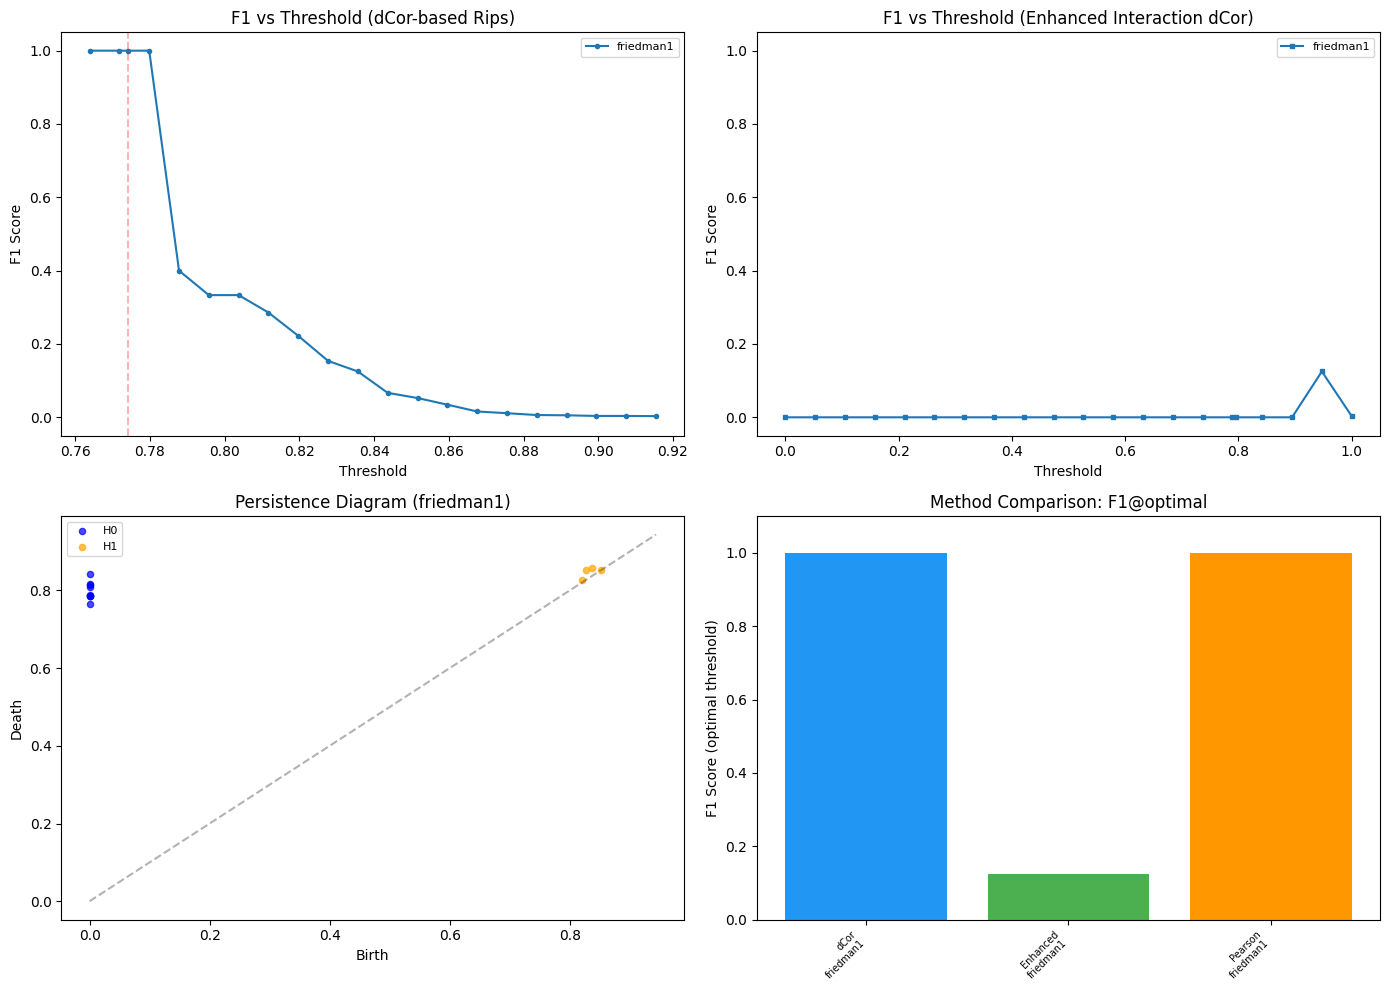

Visualization complete.


In [15]:
# ── Visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: F1 vs Threshold (dCor Rips) for friedman1
ax = axes[0, 0]
for ds_name in DATASETS_WITH_GROUND_TRUTH:
    if ds_name not in interaction_recovery:
        continue
    rec = interaction_recovery[ds_name]
    metrics = rec["metrics_by_threshold"]
    ts = sorted([float(k) for k in metrics.keys()])
    f1s = [metrics[str(round(t, 6))]["f1"] for t in ts]
    ax.plot(ts, f1s, "-o", markersize=3, label=ds_name)
    ax.axvline(rec["gap_threshold"], color="r", linestyle="--", alpha=0.3)
ax.set_xlabel("Threshold")
ax.set_ylabel("F1 Score")
ax.set_title("F1 vs Threshold (dCor-based Rips)")
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.05)

# Plot 2: Enhanced Interaction dCor F1 vs Threshold
ax = axes[0, 1]
for ds_name in DATASETS_WITH_GROUND_TRUTH:
    if ds_name not in enhanced_results or "metrics_by_threshold" not in enhanced_results[ds_name]:
        continue
    enh = enhanced_results[ds_name]
    metrics = enh["metrics_by_threshold"]
    ts = sorted([float(k) for k in metrics.keys()])
    f1s = [metrics[str(round(t, 6))]["f1"] for t in ts]
    ax.plot(ts, f1s, "-s", markersize=3, label=ds_name)
ax.set_xlabel("Threshold")
ax.set_ylabel("F1 Score")
ax.set_title("F1 vs Threshold (Enhanced Interaction dCor)")
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.05)

# Plot 3: Persistence diagram for friedman1
ax = axes[1, 0]
colors = {0: "blue", 1: "orange", 2: "green", 3: "red"}
for ds_name in ["friedman1"]:
    if ds_name not in rips_results:
        continue
    pd_data = rips_results[ds_name]["persistence_diagrams"]
    max_death = 0
    for dim, intervals in pd_data.items():
        dim = int(dim)
        if not intervals:
            continue
        births = [iv[0] for iv in intervals]
        deaths = [iv[1] for iv in intervals if np.isfinite(iv[1])]
        finite_mask = [np.isfinite(iv[1]) for iv in intervals]
        b_finite = [births[i] for i in range(len(births)) if finite_mask[i]]
        d_finite = [deaths[i] for i, fm in enumerate(finite_mask) if fm]
        if d_finite:
            max_death = max(max_death, max(d_finite))
        if b_finite:
            ax.scatter(b_finite, d_finite, c=colors.get(dim, "black"),
                       label=f"H{dim}", s=20, alpha=0.7)
    if max_death > 0:
        ax.plot([0, max_death * 1.1], [0, max_death * 1.1], "k--", alpha=0.3)
ax.set_xlabel("Birth")
ax.set_ylabel("Death")
ax.set_title("Persistence Diagram (friedman1)")
ax.legend(fontsize=8)

# Plot 4: Method comparison bar chart
ax = axes[1, 1]
methods = []
f1_values = []
for ds_name in DATASETS_WITH_GROUND_TRUTH:
    if ds_name in interaction_recovery:
        methods.append(f"dCor\n{ds_name}")
        f1_values.append(interaction_recovery[ds_name]["f1_at_optimal"])
    if ds_name in enhanced_results:
        methods.append(f"Enhanced\n{ds_name}")
        f1_values.append(enhanced_results[ds_name]["f1_at_optimal"])
    if ds_name in baseline_results:
        methods.append(f"Pearson\n{ds_name}")
        f1_values.append(baseline_results[ds_name]["f1_at_optimal"])

bar_colors = []
for m in methods:
    if "Enhanced" in m:
        bar_colors.append("#4CAF50")
    elif "Pearson" in m:
        bar_colors.append("#FF9800")
    else:
        bar_colors.append("#2196F3")

x = np.arange(len(methods))
ax.bar(x, f1_values, color=bar_colors)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=7, rotation=45, ha="right")
ax.set_ylabel("F1 Score (optimal threshold)")
ax.set_title("Method Comparison: F1@optimal")
ax.set_ylim(0, 1.1)

fig.tight_layout()
plt.show()
print("Visualization complete.")